# 02 · 最小 Graph

**继续在浏览器 Jupyter Lab 中验证**（与 01 使用同一 Kernel）。

验证最小可运行 LangGraph：

- State：`messages` + `ok`
- 单节点 `call_llm` 调大模型
- 条件边：有有效回复 → `success`，否则 → `fallback`

## 怎么跑

1. 左侧打开本文件 `02-min-graph.ipynb`
2. Kernel 确认是 **OOCL 2026 AI Agent**
3. **Run → Run All Cells**
4. 看到图结构 + `L0 graph ok` 即通关


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv

ROOT = Path.cwd()
if not (ROOT / "src" / "hello_agent").exists():
    for p in [ROOT, *ROOT.parents]:
        if (p / "src" / "hello_agent").exists():
            ROOT = p
            break
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
load_dotenv(ROOT / ".env")

print("cwd =", ROOT)
print("LLM_BASE_URL =", os.getenv("LLM_BASE_URL"))
print("LLM_MODEL =", os.getenv("LLM_MODEL"))


cwd = /Users/kunwei/Projects/oocl-agent-workshop-lab/oocl-2026-ai-agent-training
LLM_BASE_URL = https://api.deepseek.com
LLM_MODEL = deepseek-v4-flash


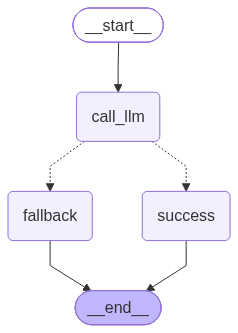

In [2]:
def show_graph(g):
    """在 notebook 展示图结构；无 PNG 后端时回退 mermaid 文本。"""
    from IPython.display import Image, display

    try:
        display(Image(g.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("PNG 不可用，打印 mermaid：", e)
        print(g.get_graph().draw_mermaid())


from hello_agent.graph import graph, run_hello

show_graph(graph)


In [ ]:
result = run_hello()
msgs = result.get("messages") or []
last = msgs[-1] if msgs else None
print("ok =", result.get("ok"))
print("last =", getattr(last, "content", last))
assert result.get("ok") is True, "图走到了 fallback，请检查 LLM 配置"
print("L0 graph ok")


可选课堂演示：另开终端在仓库根目录执行 `uv run langgraph dev`，
用浏览器打开 Studio URL，可视化同一张图（不替代本 notebook 通关）。
